In [2]:
!pip install datasets transformers nltk pandas matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from datasets import load_dataset
from transformers import BartTokenizer

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# Load CNN/DailyMail dataset from HuggingFace
dataset = load_dataset("cnn_dailymail", "3.0.0")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


In [8]:
# Look at one sample
sample = dataset['train'][0]

print("ARTICLE:\n")
print(sample['article'][:500])  # first 500 chars
print("\nSUMMARY :\n")
print(sample['highlights'])

ARTICLE:

LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as s

SUMMARY :

Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


In [9]:
# Work on a sample of 5000 for speed
import random
random.seed(42)

train_data = dataset['train'].select(range(5000))

article_lengths = [len(ex['article'].split()) for ex in train_data]
summary_lengths = [len(ex['highlights'].split()) for ex in train_data]

print("ARTICLE LENGTH (words)")
print(f"  Min    : {min(article_lengths)}")
print(f"  Max    : {max(article_lengths)}")
print(f"  Mean   : {sum(article_lengths)/len(article_lengths):.1f}")
print(f"  Median : {sorted(article_lengths)[len(article_lengths)//2]}")

print("\nSUMMARY LENGTH (words)")
print(f"  Min    : {min(summary_lengths)}")
print(f"  Max    : {max(summary_lengths)}")
print(f"  Mean   : {sum(summary_lengths)/len(summary_lengths):.1f}")
print(f"  Median : {sorted(summary_lengths)[len(summary_lengths)//2]}")

# Compression ratio (how much shorter is the summary?)
ratios = [s/a for a, s in zip(article_lengths, summary_lengths)]
print(f"\nCOMPRESSION RATIO (summary/article)")
print(f"  Mean : {sum(ratios)/len(ratios):.3f}  → summaries are ~{1//(sum(ratios)/len(ratios)):.0f}x shorter")

ARTICLE LENGTH (words)
  Min    : 18
  Max    : 1831
  Mean   : 615.2
  Median : 570

SUMMARY LENGTH (words)
  Min    : 11
  Max    : 75
  Mean   : 43.9
  Median : 45

COMPRESSION RATIO (summary/article)
  Mean : 0.093  → summaries are ~10x shorter


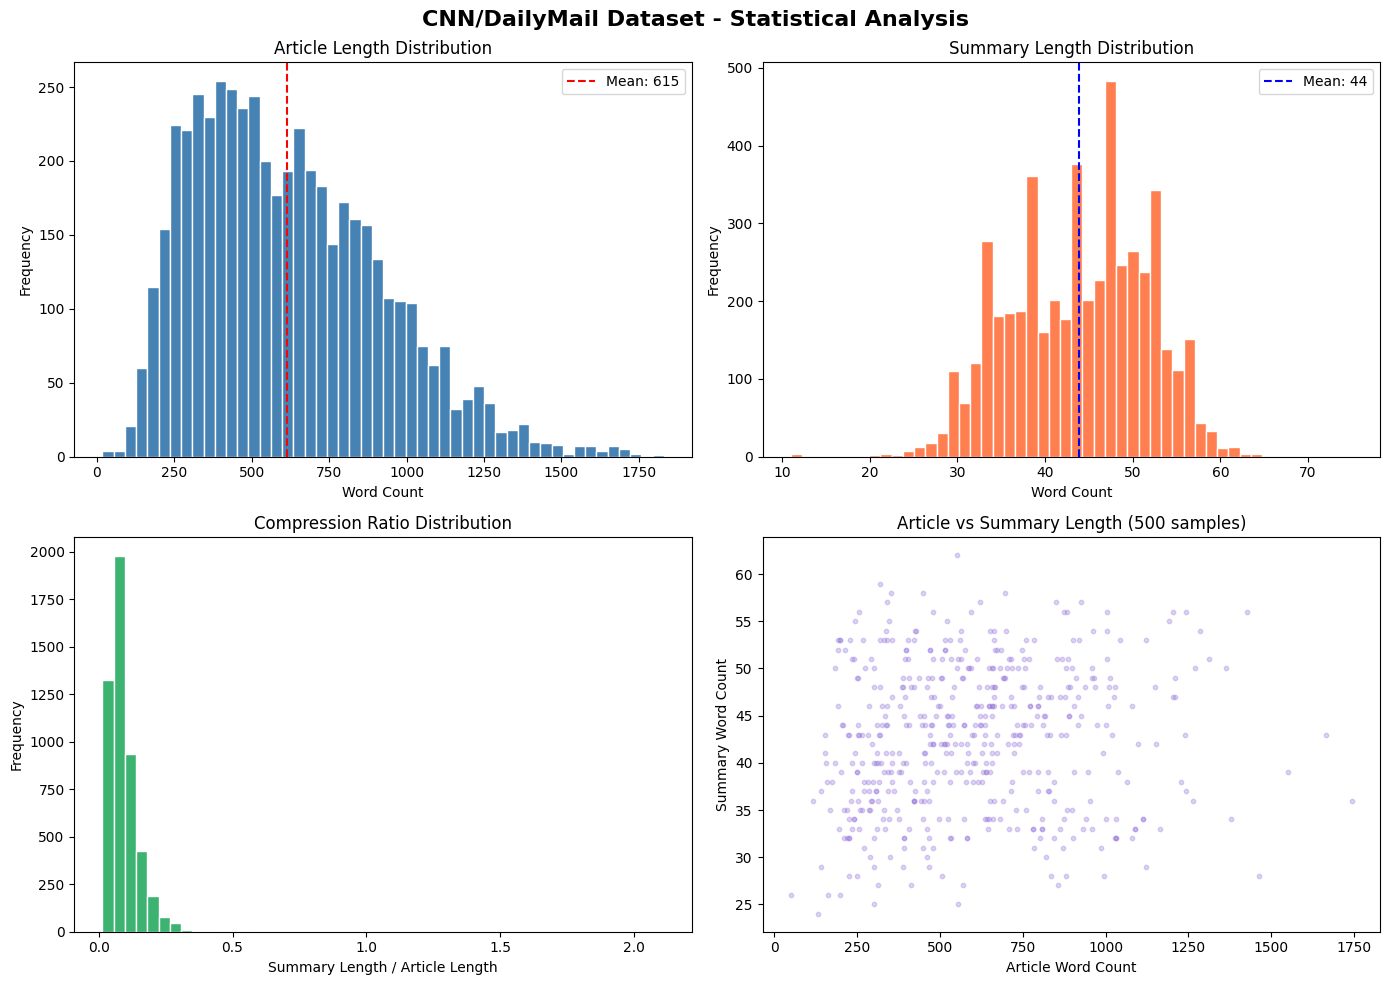

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CNN/DailyMail Dataset - Statistical Analysis', fontsize=16, fontweight='bold')

# 1. Article length distribution
axes[0, 0].hist(article_lengths, bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Article Length Distribution')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(sum(article_lengths)/len(article_lengths),
                    color='red', linestyle='--', label=f'Mean: {sum(article_lengths)/len(article_lengths):.0f}')
axes[0, 0].legend()

# 2. Summary length distribution
axes[0, 1].hist(summary_lengths, bins=50, color='coral', edgecolor='white')
axes[0, 1].set_title('Summary Length Distribution')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(sum(summary_lengths)/len(summary_lengths),
                    color='blue', linestyle='--', label=f'Mean: {sum(summary_lengths)/len(summary_lengths):.0f}')
axes[0, 1].legend()

# 3. Compression ratio distribution
axes[1, 0].hist(ratios, bins=50, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Compression Ratio Distribution')
axes[1, 0].set_xlabel('Summary Length / Article Length')
axes[1, 0].set_ylabel('Frequency')

# 4. Scatter plot - article vs summary length
axes[1, 1].scatter(article_lengths[:500], summary_lengths[:500],
                    alpha=0.3, color='mediumpurple', s=10)
axes[1, 1].set_title('Article vs Summary Length (500 samples)')
axes[1, 1].set_xlabel('Article Word Count')
axes[1, 1].set_ylabel('Summary Word Count')

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=150)# save plots
plt.show()


In [13]:
# Check for nulls / empty texts
print("  CHECKING DATA QUALITY")

empty_articles = sum(1 for ex in train_data if len(ex['article'].strip()) == 0)
empty_summaries = sum(1 for ex in train_data if len(ex['highlights'].strip()) == 0)

print(f"  Empty articles  : {empty_articles}")
print(f"  Empty summaries : {empty_summaries}")

# Check for very short articles (less than 50 words - likely bad data)
short_articles = sum(1 for l in article_lengths if l < 50)
print(f"  Articles < 50 words  : {short_articles}")

# Check for very long articles (outliers > 2000 words)
long_articles = sum(1 for l in article_lengths if l > 2000)
print(f"  Articles > 2000 words: {long_articles} ({long_articles/len(article_lengths)*100:.1f}%)")

# Check for duplicate articles
ids = [ex['id'] for ex in train_data]
print(f"\n  Total samples    : {len(ids)}")
print(f"  Unique IDs       : {len(set(ids))}")
print(f"  Duplicates       : {len(ids) - len(set(ids))}")

# Summary sentence count (multi-sentence summaries?)
sentence_counts = [len(ex['highlights'].split('\n')) for ex in train_data]
print(f"\n  SUMMARY SENTENCE COUNT")
print(f"  Mean lines per summary: {sum(sentence_counts)/len(sentence_counts):.1f}")
print(f"  Most summaries have {max(set(sentence_counts), key=sentence_counts.count)} bullet lines")

  CHECKING DATA QUALITY
  Empty articles  : 0
  Empty summaries : 0
  Articles < 50 words  : 3
  Articles > 2000 words: 0 (0.0%)

  Total samples    : 5000
  Unique IDs       : 5000
  Duplicates       : 0

  SUMMARY SENTENCE COUNT
  Mean lines per summary: 3.6
  Most summaries have 4 bullet lines


In [14]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Remove newlines and extra spaces
    text = text.replace('\n', ' ').strip()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove (CNN) -- common artifact in this dataset
    text = re.sub(r'\(CNN\)', '', text)
    text = re.sub(r'-- ', '', text)

    # 4. Remove special characters but keep punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\;\:\'\"-]', '', text)

    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_sample(example):
    example['article']    = clean_text(example['article'])
    example['highlights'] = clean_text(example['highlights'])
    return example

# Apply to dataset
print("  Cleaning dataset...")
cleaned_data = train_data.map(preprocess_sample)

# Verify
print("\n  Before cleaning:")
print(dataset['train'][0]['article'][:200])
print("\n  After cleaning:")
print(cleaned_data[0]['article'][:200])

  Cleaning dataset...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]


  Before cleaning:
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on 

  After cleaning:
LONDON, England Reuters Harry Potter star Daniel Radcliffe gains access to a reported 20 million 41.1 million fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Dani


In [15]:
# Filter out bad samples
def is_valid(example):
    art_len = len(example['article'].split())
    sum_len = len(example['highlights'].split())
    return (
        art_len >= 50 and      # not too short
        art_len <= 1500 and    # not too long
        sum_len >= 10          # summary has enough content
    )

filtered_data = cleaned_data.filter(is_valid)
print(f"Before filtering: {len(cleaned_data)}")
print(f"After filtering : {len(filtered_data)}")

# Convert to pandas and save
df = pd.DataFrame({
    'article'  : [ex['article'] for ex in filtered_data],
    'summary'  : [ex['highlights'] for ex in filtered_data],
})

df.to_csv('clean_cnn_data.csv', index=False)
print(f"\n  Saved {len(df)} clean samples to clean_cnn_data.csv")
print(df.head(3))

Filter:   0%|          | 0/5000 [00:00<?, ? examples/s]

Before filtering: 5000
After filtering : 4961

  Saved 4961 clean samples to clean_cnn_data.csv
                                             article  \
0  LONDON, England Reuters Harry Potter star Dani...   
1  Editor's note: In our Behind the Scenes series...   
2  MINNEAPOLIS, Minnesota Drivers who were on the...   

                                             summary  
0  Harry Potter star Daniel Radcliffe gets 20M fo...  
1  Mentally ill inmates in Miami are housed on th...  
2  NEW: "I thought I was going to die," driver sa...  
